In [478]:
import torch
from pathlib import Path
import ast

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt

import seaborn as sns


from sklearn.metrics import roc_auc_score, accuracy_score, f1_score
import os
import re


from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

## Non-logic helper functions

In [479]:
def load_tensor(path: Path):
    assert path.exists(), path
    return torch.load(path, map_location="cpu")

def to_numpy(x):
    if isinstance(x, torch.Tensor):
        return x.detach().cpu().numpy()
    return np.asarray(x)


## Helper functions

In [480]:

# -------------------------------------------------------------
# Get information about dataset and model 
# -------------------------------------------------------------

def get_data_dir_name_from_log(experiment_path: Path):
    log_path = experiment_path / "log.txt"
    assert log_path.exists(), log_path

    data_dir_line = None
    with log_path.open("r") as f:
        for line in f:
            if line.startswith("data_dir:"):
                data_dir_line = line.split("data_dir:", 1)[1].strip()
                break
            if line.startswith("Loading existing synthetic dataset from"):
                data_dir_line = line.split("Loading existing synthetic dataset from", 1)[1].strip()
                break

    if data_dir_line is None:
        raise ValueError(f"Could not find data directory in {log_path}")

    return Path(data_dir_line).name

def infer_data_path(experiment_path: Path):
    cfg = read_config_from_log(experiment_path)
    data_cfg = cfg["data"]
    dataset = data_cfg["dataset"]
    difficulty = data_cfg.get("experiment_type")
    data_dir_name = get_data_dir_name_from_log(experiment_path)



    candidate = Path("datasets") / dataset / difficulty / data_dir_name


    if candidate.exists():
        return candidate

    raise FileNotFoundError("Could not find data path. Tried: " + ", ".join(map(str, candidates)))


def print_data_info(experiment_path: Path):
    data_path = infer_data_path(experiment_path)
    with open(data_path / "info.txt", "r") as f:
        info_lines = f.readlines()
        for line in info_lines:
            print(line.strip())
            



def read_config_from_log(experiment_path: Path):
    log_path = experiment_path / "log.txt"
    assert log_path.exists(), log_path
    with log_path.open("r") as f:
        first_line = f.readline().strip()
    return ast.literal_eval(first_line)

def infer_dataset_difficulty_from_log(experiment_path: Path):
    cfg = read_config_from_log(experiment_path)
    data_cfg = cfg["data"]
    difficulty = data_cfg.get("experiment_type")
    return difficulty





def get_dim_data_and_model(experiment_path: Path):
    cfg = read_config_from_log(experiment_path)
    num_concepts = cfg["data"].get("num_concepts")
    num_residuals = cfg["data"].get("num_residuals")
    hid_dim = cfg["data"]["hid_dim"]
    obs_dim = cfg["data"]["obs_dim"]
    if num_concepts is None or num_residuals is None:
        raise ValueError(f"Could not find num_concepts or num_residuals in config: {cfg}")
    return num_concepts, num_residuals, hid_dim, obs_dim



# --------------------------------------------------------------
# Load data
# --------------------------------------------------------------
def load_split(experiment_path: Path, data_path: Path, split: str, num_concepts=None, num_residuals=None):
    model_split = experiment_path / split
    data_split = data_path / split

    if not model_split.exists():
        raise FileNotFoundError(
            f"Missing {model_split}. Re-run inference/training after adding deterministic analysis loaders."
        )
    assert data_split.exists(), data_split
    


    c_res_mu = load_tensor(model_split / "c_res_mu.pt")
    concept_residual_probs = load_tensor(model_split / "concepts_residuals_pred_probs_mean.pt")
    concept_residual_probs_std = load_tensor(model_split / "concepts_residuals_pred_probs_std.pt")
    concept_residual_sample_mean = load_tensor(model_split / "concepts_residuals_sample_mean.pt")
    
    res_mu = c_res_mu[:, num_concepts:]
    c_mu = c_res_mu[:, :num_concepts]
    concept_probs = concept_residual_probs[:, :num_concepts]
    residual_probs = concept_residual_probs[:, num_concepts:]
    concept_probs_std = concept_residual_probs_std[:, :num_concepts]
    residual_probs_std = concept_residual_probs_std[:, num_concepts:]
    concept_sample_mean = concept_residual_sample_mean[:, :num_concepts]
    residual_sample_mean = concept_residual_sample_mean[:, num_concepts:]
        
        


    out = {
        "res_mu": res_mu,
        "c_mu": c_mu,
        "concept_probs": concept_probs,
        "residual_probs": residual_probs,
        "concept_probs_std": concept_probs_std,
        "residual_probs_std": residual_probs_std,
        "concept_sample_mean": concept_sample_mean,
        "residual_sample_mean": residual_sample_mean,
        "hidden_residuals": load_tensor(data_split / "residuals.pt"),
        "hidden_residual_signal": load_tensor(data_split / "residual_signal.pt"),
        "concepts": load_tensor(data_split / "concepts.pt"),
        "x": load_tensor(data_split / "x.pt"),
        "y": load_tensor(data_split / "y.pt"),
        "w_hid": load_tensor(data_split / "w_hid.pt"),
        "w_obs": load_tensor(data_split / "w_obs.pt"), 
    }



    # Ensure number of samples in model outputs matches number of samples in data
    n_model = out["res_mu"].shape[0]
    n_data = out["hidden_residuals"].shape[0]
    assert n_model == n_data, (
        f"{split} row mismatch: model residuals have {n_model} rows, "
        f"but hidden residual labels have {n_data}. The residual dump likely used a shuffled/drop_last loader."
    )
    assert out["residual_probs"].shape[0] == n_data
    assert out["residual_sample_mean"].shape[0] == n_data

    return out








# -------------------------------------------------------------
# Test metrics of concept model and linear model
# --------------------------------------------------------------
def get_metrics_dataset_linear_model(full_model_path, dataset_difficulty, dataset="synthetic_res_scbm", get_res_used_model=False):
    full_data_path = get_data_dir_name_from_log(full_model_path)
    data_dir_name = full_data_path.split("/")[-1]
    print(f"data_dir_name: {data_dir_name}")
    linear_models_dir = os.path.join("experiments", "linear_head", dataset, dataset_difficulty)
    linear_model_path = None
    if get_res_used_model:
        model_name_start = data_dir_name + "_trueResUsed_True"
    else:
        model_name_start = data_dir_name + "_trueResUsed_False"
    for model_dir in os.listdir(linear_models_dir):
        if model_dir.startswith(model_name_start):
            linear_model_path = model_dir
            break
    if linear_model_path is None:
        return None  # No matching linear model found
    with open(os.path.join(linear_models_dir, linear_model_path, "log.txt"), "r") as f:
        lines = f.readlines()
        for line in lines:
            if "Test" in line:
                test_line = line
                break
        y_accuracy = re.findall(r"Final Test Accuracy:\s*([0-9.]+)", test_line)[0]
        
    return float(y_accuracy)


def test_metrics(full_model_path):
    metrics = {}
    with open(os.path.join(full_model_path, "log.txt"), "r") as f:
        lines = f.readlines()
        for line in lines:
            if "Test" in line:
                test_line = line
                break
        y_accuracy = re.findall(r"y_accuracy:\s*([0-9.]+)", test_line)[0]
        c_accuracy = re.findall(r"c_accuracy:\s*([0-9.]+)", test_line)[0]
        c_auc = re.findall(r"c_AUROC:\s*([0-9.]+)", test_line)[0]
        metrics["y_accuracy"] = float(y_accuracy)
        metrics["c_accuracy"] = float(c_accuracy)
        metrics["c_auc"] = float(c_auc)
    return metrics  


# -------------------------------------------------------------
# Edit final dataframes
# --------------------------------------------------------------


def add_weights(df, w_hid, column_name="hidden_idx"):
    if not column_name in df.columns:
        raise ValueError(f"DataFrame must contain {column_name} column to add weights.")
   
    # Add weights to the DataFrame based on hidden_idx
    df["w_hid"] = df[column_name].apply(lambda idx: w_hid[idx].item() if idx < len(w_hid) else None)
    df["abs_w_hid"] = df["w_hid"].abs()
    df.sort_values(by="abs_w_hid", ascending=False, inplace=True)
    return df






## Post-analysis helper functions

In [481]:
def calculate_auc(true_val, pred_val):
    auc = roc_auc_score(true_val, pred_val)
    if auc < 0.5:
        print("Warning: AUC < 0.5, inverting predictions.")
        auc = 1 - auc
        direction = "negative"
    else:
        direction = "positive"
    return auc, direction



## Dataset helper functions

In [482]:
def load_split_data(full_data_path, split):
    data_path = Path(full_data_path)
    data_split = data_path / split
    assert data_path.exists(), data_path
    
    concepts = load_tensor(data_split / "concepts.pt")
    x = load_tensor(data_split / "x.pt")
    y = load_tensor(data_split / "y.pt")
    w_hid = load_tensor(data_split / "w_hid.pt")
    w_obs = load_tensor(data_split / "w_obs.pt")
    residuals = load_tensor(data_split / "residuals.pt")
    
    return {
        "concepts": concepts,
        "x": x,
        "y": y,
        "w_hid": w_hid,
        "w_obs": w_obs,
        "residuals": residuals
    }
    
    
def print_data_info_from_data_path(full_data_path):
    data_path = Path(full_data_path)
    info_file = data_path / "info.txt"
    assert info_file.exists(), info_file
    with open(info_file, "r") as f:
        for line in f:
            print(line.strip())

    

    
    

## Specify experiment

In [483]:
# EXPERIMENT_PATH = Path("experiments/scbm_residual/synthetic_res_scbm/hard/"
#                        "alpha_0.5_beta_2.0_rho_cr0.0_rho_cc0.0_rho_rr0.0_hard_hid20_R20_sparse_200_epochs_save_c_res_2026-06-15_22-56-15_16428"
# )

# Sigma_x = 0.1
# EXPERIMENT_PATH = Path("experiments/scbm_residual/synthetic_res_scbm/easy/"
#                        "alpha_1.0_beta_1.0_rho_cr0.0_rho_cc0.0_rho_rr0.0_TEST_DATA_SET_2026-06-16_16-16-11_10b94"
# )

# # Sigma_x = 0.5
# EXPERIMENT_PATH = Path("experiments/scbm_residual/synthetic_res_scbm/easy/"
#                        "alpha_1.0_beta_2.0_rho_cr0.0_rho_cc0.0_rho_rr0.0_TEST_DATA_SET_2026-06-16_17-51-47_c78ba"
# )


EXPERIMENT_PATH = Path("experiments/scbm_residual/synthetic_res_scbm/hard/"
                       "alpha_1.0_beta_1.0_rho_cr0.0_rho_cc0.0_rho_rr0.0_sigma_x_0.1_hard_hid20_R20_sparse_200_epochs_2026-06-17_13-22-33_ba6fd"
)
        
      
     
 
      
                     

DATA__PATH = infer_data_path(EXPERIMENT_PATH)


assert EXPERIMENT_PATH.exists(), EXPERIMENT_PATH
EXPERIMENT_PATH

DATA__PATH = infer_data_path(EXPERIMENT_PATH)

## Datasets and model specifications

In [484]:
num_concepts, num_residuals, hid_dim, obs_dim = get_dim_data_and_model(EXPERIMENT_PATH)
print(f"num_concepts: {num_concepts}, num_residuals: {num_residuals}, hid_dim: {hid_dim}, obs_dim: {obs_dim}")

# Load data splits
train_data = load_split(EXPERIMENT_PATH, DATA__PATH, "train", num_concepts=num_concepts, num_residuals=num_residuals)
val_data = load_split(EXPERIMENT_PATH, DATA__PATH, "val", num_concepts=num_concepts, num_residuals=num_residuals)
test_data = load_split(EXPERIMENT_PATH, DATA__PATH, "test", num_concepts=num_concepts, num_residuals=num_residuals)

splits = {"train": train_data, "val": val_data, "test": test_data}

for split_name, data in splits.items():
    print(f"{split_name} split:")
    for key in ["x", "res_mu", "residual_probs", "residual_sample_mean", "hidden_residuals", "hidden_residual_signal", "concepts", "y"]:
        print(f"  {key:24s} {tuple(data[key].shape)}")

num_concepts: 10, num_residuals: 20, hid_dim: 20, obs_dim: 10
train split:
  x                        (30000, 100)
  res_mu                   (30000, 20)
  residual_probs           (30000, 20)
  residual_sample_mean     (30000, 20)
  hidden_residuals         (30000, 20)
  hidden_residual_signal   (30000, 20)
  concepts                 (30000, 10)
  y                        (30000,)
val split:
  x                        (10000, 100)
  res_mu                   (10000, 20)
  residual_probs           (10000, 20)
  residual_sample_mean     (10000, 20)
  hidden_residuals         (10000, 20)
  hidden_residual_signal   (10000, 20)
  concepts                 (10000, 10)
  y                        (10000,)
test split:
  x                        (10000, 100)
  res_mu                   (10000, 20)
  residual_probs           (10000, 20)
  residual_sample_mean     (10000, 20)
  hidden_residuals         (10000, 20)
  hidden_residual_signal   (10000, 20)
  concepts                 (10000, 10)
  y     

### Dataset weights

In [485]:
w_hid = train_data["w_hid"]
w_obs = train_data["w_obs"]

w_hid_and_w_obs = torch.cat([w_hid, w_obs], dim=0)

idx = [f"hid_{i}" for i in range(w_hid.shape[0])] + [f"obs_{i}" for i in range(w_obs.shape[0])]
df_w_hid_and_w_obs = pd.DataFrame({
    "idx": idx,
    "weight": w_hid_and_w_obs.detach().cpu().numpy(),
    "abs_weight": w_hid_and_w_obs.abs().detach().cpu().numpy(),
})

# only display non-zero abs weights
df_w_hid_and_w_obs = df_w_hid_and_w_obs[df_w_hid_and_w_obs["abs_weight"] > 1e-8]
display(df_w_hid_and_w_obs.sort_values("abs_weight", ascending=False))


data_difficulty = infer_dataset_difficulty_from_log(EXPERIMENT_PATH)
print(f"Dataset difficulty: {data_difficulty}")
print_data_info(EXPERIMENT_PATH)

,idx,weight,abs_weight
20,obs_0,0.916100,0.916100
18,hid_18,-0.705692,0.705692
2,hid_2,-0.648612,0.648612
23,obs_3,-0.384910,0.384910
9,hid_9,0.230210,0.230210
19,hid_19,-0.150507,0.150507
27,obs_7,0.112267,0.112267
7,hid_7,0.075182,0.075182


Dataset difficulty: hard
rho_cr (correlation between linked concepts and residuals): 0.0
rho_cc (within-block correlation for observed concepts): 0.0
rho_rr (within-block correlation for hidden concepts): 0.0
alpha: 1.0, beta: 1.0
Task sparsity for observed concepts: 0.3, Task sparsity for hidden concepts: 0.25
Sigma_x (noise level in x): 0.1
num_concepts: 10, num_residuals: 20
Data created for model saved at: /cluster/home/smarcou/work/experiments_scbm/scbm_residual/synthetic_res_scbm/hard/alpha_1.0_beta_1.0_rho_cr0.0_rho_cc0.0_rho_rr0.0_sigma_x_0.1_hard_hid20_R20_sparse_200_epochs_2026-06-17_13-22-33_ba6fd


## Model performance

In [486]:
dataset_difficulty = infer_dataset_difficulty_from_log(EXPERIMENT_PATH)
linear_y_with_residuals = get_metrics_dataset_linear_model(EXPERIMENT_PATH, dataset_difficulty=dataset_difficulty, dataset="synthetic_res_scbm", get_res_used_model=True)
linear_y_without_residuals = get_metrics_dataset_linear_model(EXPERIMENT_PATH, dataset_difficulty=dataset_difficulty, dataset="synthetic_res_scbm", get_res_used_model=False)

test_metrics_dict = test_metrics(EXPERIMENT_PATH)
test_metrics_dict["linear_model_y_accuracy_with_res"] = linear_y_with_residuals
test_metrics_dict["linear_model_y_accuracy_no_res"] = linear_y_without_residuals
test_metrics_df = pd.DataFrame([test_metrics_dict])
display(test_metrics_df)

data_dir_name: cluster_a_1.0_b_1.0_rho_cr0.0_rho_cc0.0_rho_rr0.0_r_sparsity_0.25_c_sparsity_0.3_sigmax_0.1_seed_0
data_dir_name: cluster_a_1.0_b_1.0_rho_cr0.0_rho_cc0.0_rho_rr0.0_r_sparsity_0.25_c_sparsity_0.3_sigmax_0.1_seed_0


,y_accuracy,c_accuracy,c_auc,linear_model_y_accuracy_with_res,linear_model_y_accuracy_no_res
0,0.932,0.889,0.942,None,None


## Distributed probe baseline

Train a seperate logistic regression model for each hidden concept, to see how much of the hidden concept information is stored in the full residual channel

In [487]:
def probe_baseline(H_pred_train, H_true_train, H_pred_test, H_true_test):
    H_pred_train = to_numpy(H_pred_train).astype(float)
    H_pred_test = to_numpy(H_pred_test).astype(float)
    H_true_train = to_numpy(H_true_train).astype(float)
    H_true_test = to_numpy(H_true_test).astype(float)
    
    output = []

    # For each hidden concept, fit logistic regression model 
    for h in range(H_true_train.shape[1]):
        clf = make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000, class_weight="balanced", random_state=0))
        clf.fit(H_pred_train, H_true_train[:, h])
        probs = clf.predict_proba(H_pred_test)[:, 1]
        preds = (probs >= 0.5).astype(int)
        
        output.append({
            "hidden_idx": h,
            "distributed_auc": roc_auc_score(H_true_test[:, h], probs),
            "distributed_accuracy": accuracy_score(H_true_test[:, h], preds),
            "distributed_f1": f1_score(H_true_test[:, h], preds),
        })

    return pd.DataFrame(output)
        
    
    
probe_eval_hidden = probe_baseline(
    splits["train"]["res_mu"],
    splits["train"]["hidden_residuals"],
    splits["test"]["res_mu"],
    splits["test"]["hidden_residuals"],
)

df_probe_eval_hidden = add_weights(probe_eval_hidden, w_hid)
display(df_probe_eval_hidden)
    
    

,hidden_idx,distributed_auc,distributed_accuracy,distributed_f1,w_hid,abs_w_hid
18,18,0.733369,0.6689,0.664369,-0.705692,0.705692
2,2,0.729415,0.6691,0.663549,-0.648612,0.648612
9,9,0.641248,0.6030,0.607863,0.230210,0.230210
19,19,0.601043,0.5685,0.572645,-0.150507,0.150507
7,7,0.576210,0.5534,0.550161,0.075182,0.075182
12,12,0.598209,0.5681,0.565012,0.000000,0.000000
17,17,0.625608,0.5922,0.598147,0.000000,0.000000
16,16,0.592290,0.5678,0.575775,0.000000,0.000000
15,15,0.585549,0.5603,0.561397,0.000000,0.000000
14,14,0.580683,0.5577,0.561254,0.000000,0.000000


In [488]:
# Calculate AUC for observed concepts, to be used as upper bound for hidden concepts
probe_eval_observed = probe_baseline(
    splits["train"]["c_mu"],
    splits["train"]["concepts"],
    splits["test"]["c_mu"],
    splits["test"]["concepts"],
)

df_probe_eval_observed = add_weights(probe_eval_observed, w_hid)
display(df_probe_eval_observed)
    

,hidden_idx,distributed_auc,distributed_accuracy,distributed_f1,w_hid,abs_w_hid
2,2,0.949965,0.8975,0.895802,-0.648612,0.648612
9,9,0.947088,0.8905,0.887934,0.230210,0.230210
7,7,0.944480,0.8929,0.889462,0.075182,0.075182
0,0,0.943336,0.8849,0.884217,0.000000,0.000000
1,1,0.946994,0.8928,0.890366,0.000000,0.000000
3,3,0.936010,0.8762,0.872634,0.000000,0.000000
4,4,0.943968,0.8875,0.884556,0.000000,0.000000
5,5,0.943591,0.8871,0.884737,0.000000,0.000000
6,6,0.932071,0.8717,0.866840,0.000000,0.000000
8,8,0.936301,0.8756,0.872619,0.000000,0.000000


## MLP predicting from raw input x

In [489]:

# Predict observed concepts directly from raw input x with a small MLP.
# Targets are multi-label binary concepts, so the model emits one logit per concept.

class ConceptMLP(nn.Module):
    def __init__(self, input_dim, num_concepts, hidden_dims=(128, 64), dropout=0.1):
        super().__init__()
        layers = []
        prev_dim = input_dim
        for hidden_dim in hidden_dims:
            layers.extend([
                nn.Linear(prev_dim, hidden_dim),
                nn.ReLU(),
                nn.Dropout(dropout),
            ])
            prev_dim = hidden_dim
        layers.append(nn.Linear(prev_dim, num_concepts))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)


def make_concept_loader(split_data, batch_size=512, shuffle=False, prediction_column="concepts"):
    dataset = torch.utils.data.TensorDataset(
        split_data["x"].float(),
        split_data[prediction_column].float(),
    )
    return torch.utils.data.DataLoader(dataset, batch_size=batch_size, shuffle=shuffle)

# Run inference with MLP
def evaluate_concept_mlp(model, loader, device, prediction_column="concepts"):
    model.eval()
    losses = []
    all_logits = []
    all_targets = []
    with torch.no_grad():
        for xb, cb in loader:
            xb = xb.to(device)
            cb = cb.to(device)
            logits = model(xb)
            loss = F.binary_cross_entropy_with_logits(logits, cb)
            losses.append(loss.item() * xb.shape[0])
            all_logits.append(logits.cpu())
            all_targets.append(cb.cpu())

    logits = torch.cat(all_logits)
    targets = torch.cat(all_targets)
    probs = torch.sigmoid(logits)
    preds = (probs >= 0.5).float()

    metrics = {
        "loss": sum(losses) / len(loader.dataset),
        "element_accuracy": (preds == targets).float().mean().item(),
        "exact_match_accuracy": (preds == targets).all(dim=1).float().mean().item(),
        "macro_f1": f1_score(to_numpy(targets), to_numpy(preds), average="macro", zero_division=0),
    }

    try:
        per_concept_auc = [
            roc_auc_score(to_numpy(targets[:, j]), to_numpy(probs[:, j]))
            for j in range(targets.shape[1])
            if len(np.unique(to_numpy(targets[:, j]))) > 1
        ]
        metrics["macro_auc"] = float(np.mean(per_concept_auc))
    except ValueError:
        metrics["macro_auc"] = np.nan
        
        
        
        
    per_concept_metrics = []

    if prediction_column == "concepts":
        column_idx = "concept_idx"
    else:
        column_idx = "hidden_concept_idx"



    for j in range(targets.shape[1]):
        y_true = to_numpy(targets[:, j])
        y_prob = to_numpy(probs[:, j])
        y_pred = to_numpy(preds[:, j])

        row = {
            column_idx: j,
            "accuracy": accuracy_score(y_true, y_pred),
            "f1": f1_score(y_true, y_pred, zero_division=0),
        }

        if len(np.unique(y_true)) > 1:
            row["auc"] = roc_auc_score(y_true, y_prob)
        else:
            row["auc"] = np.nan

        per_concept_metrics.append(row)
    

    metrics["per_concept_metrics"] = pd.DataFrame(per_concept_metrics)

    return metrics, probs

# Train MLP
def train_concept_mlp_from_x(
    train_data,
    val_data,
    test_data,
    hidden_dims=(128, 64),
    dropout=0.1,
    lr=1e-3,
    weight_decay=1e-4,
    batch_size=512,
    epochs=100,
    patience=10,
    prediction_column="concepts"
):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    x_mean = train_data["x"].float().mean(dim=0, keepdim=True)
    x_std = train_data["x"].float().std(dim=0, keepdim=True).clamp_min(1e-6)
    normalized_splits = {}
    for split_name, split_data in {"train": train_data, "val": val_data, "test": test_data}.items():
        normalized_splits[split_name] = dict(split_data)
        normalized_splits[split_name]["x"] = (split_data["x"].float() - x_mean) / x_std

    train_loader = make_concept_loader(normalized_splits["train"], batch_size=batch_size, shuffle=True, prediction_column=prediction_column)
    val_loader = make_concept_loader(normalized_splits["val"], batch_size=batch_size, prediction_column=prediction_column)
    test_loader = make_concept_loader(normalized_splits["test"], batch_size=batch_size, prediction_column=prediction_column)

    model = ConceptMLP(
        input_dim=train_data["x"].shape[1],
        num_concepts=train_data[prediction_column].shape[1],
        hidden_dims=hidden_dims,
        dropout=dropout,
    ).to(device)
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)

    best_state = None
    best_val_loss = float("inf")
    best_epoch = 0
    epochs_without_improvement = 0
    history = []

    for epoch in range(1, epochs + 1):
        model.train()
        train_loss = 0.0
        for xb, cb in train_loader:
            xb = xb.to(device)
            cb = cb.to(device)
            optimizer.zero_grad()
            loss = F.binary_cross_entropy_with_logits(model(xb), cb)
            loss.backward()
            optimizer.step()
            train_loss += loss.item() * xb.shape[0]
        train_loss /= len(train_loader.dataset)

        val_metrics, _ = evaluate_concept_mlp(model, val_loader, device, prediction_column=prediction_column)
        history.append({"epoch": epoch, "train_loss": train_loss, **{f"val_{k}": v for k, v in val_metrics.items()}})

        if val_metrics["loss"] < best_val_loss:
            best_val_loss = val_metrics["loss"]
            best_epoch = epoch
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            epochs_without_improvement = 0
        else:
            epochs_without_improvement += 1
            if epochs_without_improvement >= patience:
                break

    model.load_state_dict(best_state)
    test_metrics, test_concept_probs_from_x = evaluate_concept_mlp(model, test_loader, device, prediction_column=prediction_column)
    per_concept_metrics = test_metrics.pop("per_concept_metrics")
    metrics = pd.DataFrame([test_metrics], index=["test"])
    return {
        "model": model,
        "metrics": metrics,
        "history": pd.DataFrame(history),
        "best_epoch": best_epoch,
        "x_mean": x_mean,
        "x_std": x_std,
        "test_concept_probs_from_x": test_concept_probs_from_x,
        "per_concept_metrics": per_concept_metrics,
    }


concept_mlp_results = train_concept_mlp_from_x(train_data, val_data, test_data, prediction_column="concepts")
print(f"Best validation epoch: {concept_mlp_results['best_epoch']}")
display(concept_mlp_results["metrics"][["loss", "element_accuracy", "exact_match_accuracy", "macro_f1", "macro_auc"]])




Best validation epoch: 77


,loss,element_accuracy,exact_match_accuracy,macro_f1,macro_auc
test,0.266169,0.89385,0.3239,0.886645,0.942344


In [490]:
print(concept_mlp_results["per_concept_metrics"])

   concept_idx  accuracy        f1       auc
0            0    0.8936  0.888235  0.944322
1            1    0.8970  0.890635  0.947062
2            2    0.9057  0.900622  0.949784
3            3    0.8843  0.876508  0.936202
4            4    0.8928  0.884929  0.940211
5            5    0.8950  0.888227  0.945802
6            6    0.8819  0.871477  0.932772
7            7    0.9019  0.894505  0.945166
8            8    0.8824  0.873955  0.935308
9            9    0.9039  0.897362  0.946810


In [491]:
concept_mlp_results = train_concept_mlp_from_x(train_data, val_data, test_data, prediction_column="hidden_residuals")
print(f"Best validation epoch: {concept_mlp_results['best_epoch']}")
display(concept_mlp_results["metrics"][["loss", "element_accuracy", "exact_match_accuracy", "macro_f1", "macro_auc"]])


print(concept_mlp_results["per_concept_metrics"])

Best validation epoch: 98


,loss,element_accuracy,exact_match_accuracy,macro_f1,macro_auc
test,0.275847,0.889355,0.0987,0.880908,0.939042


    hidden_concept_idx  accuracy        f1       auc
0                    0    0.9049  0.897621  0.949925
1                    1    0.8862  0.876973  0.935459
2                    2    0.8915  0.881563  0.941881
3                    3    0.8811  0.871306  0.932357
4                    4    0.8971  0.888552  0.947589
5                    5    0.8963  0.889055  0.945672
6                    6    0.8980  0.890932  0.945886
7                    7    0.8915  0.879431  0.937477
8                    8    0.8771  0.867579  0.928135
9                    9    0.8931  0.887981  0.939529
10                  10    0.8926  0.883413  0.940454
11                  11    0.8840  0.876805  0.935258
12                  12    0.8750  0.864042  0.933106
13                  13    0.8867  0.877075  0.937933
14                  14    0.8931  0.886578  0.936708
15                  15    0.9003  0.893380  0.948368
16                  16    0.8934  0.885426  0.943890
17                  17    0.8834  0.875294  0.

## Raw axis analysis

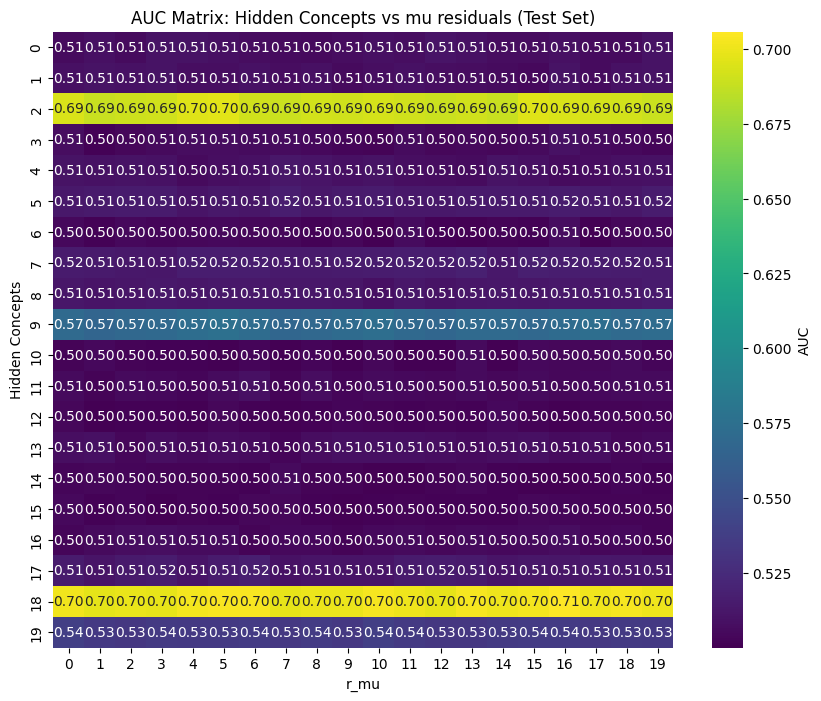

,idx,weight,abs_weight
20,obs_0,0.916100,0.916100
18,hid_18,-0.705692,0.705692
2,hid_2,-0.648612,0.648612
23,obs_3,-0.384910,0.384910
9,hid_9,0.230210,0.230210
19,hid_19,-0.150507,0.150507
27,obs_7,0.112267,0.112267
7,hid_7,0.075182,0.075182


In [492]:
def calculate_auc(true_val, pred_val):
    auc = roc_auc_score(true_val, pred_val)
    if auc < 0.5:
        auc = 1 - auc
        direction = "negative"
    else:
        direction = "positive"
    return auc


def matrix_to_dataframe(matrix, row_title="hidden_idx", col_title="residual_idx", value_name="auc"):
    rows, cols = np.indices(matrix.shape)
    df = pd.DataFrame({
        row_title: rows.ravel(),
        col_title: cols.ravel(),
        value_name: matrix.ravel(),
    })
    return df

def auc_matrix(hidden_concepts, residuals):
    num_hidden_concepts = hidden_concepts.shape[1]
    num_residuals = residuals.shape[1]
    
    # Create matrix to store AUC values
    aucs_matrix = np.zeros((num_hidden_concepts, num_residuals))
    for j in range(num_hidden_concepts):
        for k in range(num_residuals):
            if len(np.unique(hidden_concepts[:, j])) > 1:
                aucs_matrix[j, k] = calculate_auc(hidden_concepts[:, j], residuals[:, k])
            else:
                aucs_matrix[j, k] = np.nan
                
   
  
    
    
    return aucs_matrix


auc_matrix_test = auc_matrix(to_numpy(test_data["hidden_residuals"]), to_numpy(test_data["res_mu"]))

def plot_heatmap(auc_matrix, title="AUC Matrix: Hidden Concepts vs Residuals (Test Set)", x_label="c_res", y_label="Hidden Concepts"):
    if sns is None:
        raise ImportError("Seaborn is not installed. Please install seaborn to plot heatmaps.")
    
    plt.figure(figsize=(10, 8))
    sns.heatmap(auc_matrix, annot=True, fmt=".2f", cmap="viridis", cbar_kws={'label': 'AUC'})
    plt.title(title)
    plt.xlabel(x_label)
    plt.ylabel(y_label)
    plt.show()

plot_heatmap(auc_matrix_test, title="AUC Matrix: Hidden Concepts vs mu residuals (Test Set)", x_label="r_mu", y_label="Hidden Concepts")


# make dataframe with hidden_idx, resisual idx as columns and AUC as values
# auc_test_df = matrix_to_dataframe(auc_matrix_test, row_title="hidden_idx", col_title="residual_idx", value_name="auc")

# auc_test_df = add_weights(auc_test_df, w_hid, column_name="hidden_idx")

# display(auc_test_df.sort_values("abs_w_hid", ascending=False).head(40))


w_hid = train_data["w_hid"]
w_obs = train_data["w_obs"]

w_hid_and_w_obs = torch.cat([w_hid, w_obs], dim=0)

idx = [f"hid_{i}" for i in range(w_hid.shape[0])] + [f"obs_{i}" for i in range(w_obs.shape[0])]
df_w_hid_and_w_obs = pd.DataFrame({
    "idx": idx,
    "weight": w_hid_and_w_obs.detach().cpu().numpy(),
    "abs_weight": w_hid_and_w_obs.abs().detach().cpu().numpy(),
})

# only display non-zero abs weights
df_w_hid_and_w_obs = df_w_hid_and_w_obs[df_w_hid_and_w_obs["abs_weight"] > 1e-8]
display(df_w_hid_and_w_obs.sort_values("abs_weight", ascending=False))


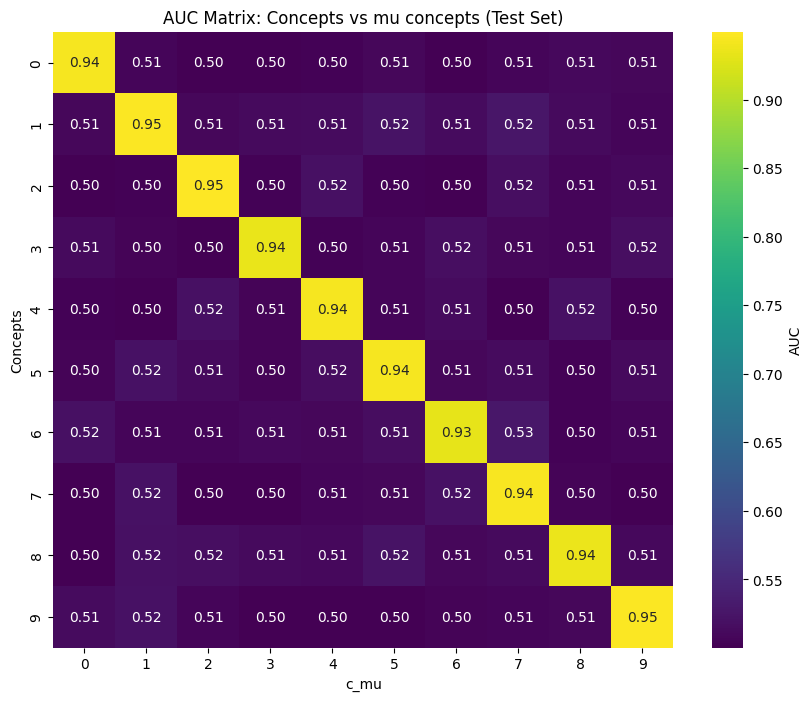

,idx,weight,abs_weight
20,obs_0,0.916100,0.916100
18,hid_18,-0.705692,0.705692
2,hid_2,-0.648612,0.648612
23,obs_3,-0.384910,0.384910
9,hid_9,0.230210,0.230210
19,hid_19,-0.150507,0.150507
27,obs_7,0.112267,0.112267
7,hid_7,0.075182,0.075182


In [493]:
auc_matrix_test = auc_matrix(to_numpy(test_data["concepts"]), to_numpy(test_data["c_mu"]))

plot_heatmap(auc_matrix_test, title="AUC Matrix: Concepts vs mu concepts (Test Set)", x_label="c_mu", y_label="Concepts")


w_hid = train_data["w_hid"]
w_obs = train_data["w_obs"]

w_hid_and_w_obs = torch.cat([w_hid, w_obs], dim=0)

idx = [f"hid_{i}" for i in range(w_hid.shape[0])] + [f"obs_{i}" for i in range(w_obs.shape[0])]
df_w_hid_and_w_obs = pd.DataFrame({
    "idx": idx,
    "weight": w_hid_and_w_obs.detach().cpu().numpy(),
    "abs_weight": w_hid_and_w_obs.abs().detach().cpu().numpy(),
})

# only display non-zero abs weights
df_w_hid_and_w_obs = df_w_hid_and_w_obs[df_w_hid_and_w_obs["abs_weight"] > 1e-8]
display(df_w_hid_and_w_obs.sort_values("abs_weight", ascending=False))


## Try different datasets

In [494]:
root = "/Users/stephenmarcou/Documents/ETH Zurich/Cambridge/Code/SCBM_implementation/datasets/synthetic_res_scbm/test_data_sets"
data_difficulty = "hard"
relative_data_dir_name = "local_a_1.0_b_2.0_rho_cr0_rho_cc0.0_rho_rr0.0_r_sparsity_0.25_c_sparsity_0.3_sigmax_0.1_seed_0"
full_data_path = f"{root}/{data_difficulty}/{relative_data_dir_name}"


print_data_info_from_data_path(full_data_path)





train_data = load_split_data(full_data_path, "train")
val_data = load_split_data(full_data_path, "val")
test_data = load_split_data(full_data_path, "test")

w_hid = train_data["w_hid"]
w_obs = train_data["w_obs"]

w_hid_and_w_obs = torch.cat([w_hid, w_obs], dim=0)

idx = [f"hid_{i}" for i in range(w_hid.shape[0])] + [f"obs_{i}" for i in range(w_obs.shape[0])]
df_w_hid_and_w_obs = pd.DataFrame({
    "idx": idx,
    "weight": w_hid_and_w_obs.detach().cpu().numpy(),
    "abs_weight": w_hid_and_w_obs.abs().detach().cpu().numpy(),
})

df_w_hid_and_w_obs = df_w_hid_and_w_obs.sort_values("abs_weight", ascending=False)
df_w_hid_and_w_obs = df_w_hid_and_w_obs[df_w_hid_and_w_obs["abs_weight"] > 1e-8]
display(df_w_hid_and_w_obs)
    

concept_mlp_results = train_concept_mlp_from_x(train_data, val_data, test_data)
print(f"Best validation epoch: {concept_mlp_results['best_epoch']}")
display(concept_mlp_results["metrics"][["loss", "element_accuracy", "exact_match_accuracy", "macro_f1", "macro_auc"]])

print(concept_mlp_results["per_concept_metrics"])





rho_cr (correlation between linked concepts and residuals): 0
rho_cc (within-block correlation for observed concepts): 0.0
rho_rr (within-block correlation for hidden concepts): 0.0
alpha: 1.0, beta: 2.0
Task sparsity for observed concepts: 0.3, Task sparsity for hidden concepts: 0.25
Sigma_x (noise level in x): 0.1
num_concepts: 10, num_residuals: 20


,idx,weight,abs_weight
20,obs_0,0.916100,0.916100
18,hid_18,-0.705692,0.705692
2,hid_2,-0.648612,0.648612
23,obs_3,-0.384910,0.384910
9,hid_9,0.230210,0.230210
19,hid_19,-0.150507,0.150507
27,obs_7,0.112267,0.112267
7,hid_7,0.075182,0.075182


Best validation epoch: 49


,loss,element_accuracy,exact_match_accuracy,macro_f1,macro_auc
test,0.267071,0.8928,0.3205,0.885978,0.942364


   concept_idx  accuracy        f1       auc
0            0    0.8909  0.885795  0.943101
1            1    0.8969  0.890540  0.946795
2            2    0.9029  0.897972  0.948880
3            3    0.8824  0.875159  0.937491
4            4    0.8944  0.887636  0.942284
5            5    0.8956  0.889031  0.943472
6            6    0.8794  0.869197  0.932450
7            7    0.9014  0.894206  0.945333
8            8    0.8828  0.874438  0.937271
9            9    0.9013  0.895809  0.946559
